# Análisis Exploratorio — Categoría Pet Shop

**Proyecto:** Sistema de Recomendación para E-commerce  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objetivo:** Entender el comportamiento de la categoría pet_shop, caracterizar a sus clientes y productos, 
e identificar el enfoque más adecuado para el sistema de recomendación.

---

## 1. Configuración e Importación de Datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (10, 5)

In [18]:
# BASE_PATH se detecta automáticamente desde la carpeta donde está el notebook.
# Asegúrate de que la carpeta 'dataPF' esté en el mismo directorio que este archivo.
BASE_PATH = os.path.join(os.getcwd(), "dataPF")

print("Ruta de datos detectada:", BASE_PATH)
print("Archivos disponibles:", [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')])
print()

products    = pd.read_csv(os.path.join(BASE_PATH, "olist_products_dataset.csv"))
order_items = pd.read_csv(os.path.join(BASE_PATH, "olist_order_items_dataset.csv"))
orders      = pd.read_csv(os.path.join(BASE_PATH, "olist_orders_dataset.csv"))
reviews     = pd.read_csv(os.path.join(BASE_PATH, "olist_order_reviews_dataset.csv"))
customers   = pd.read_csv(os.path.join(BASE_PATH, "olist_customers_dataset.csv"))

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")

print("Datasets cargados:")
for nombre, df in [("products",products),("order_items",order_items),
                   ("orders",orders),("reviews",reviews),("customers",customers)]:
    print(f"  {nombre:<15} {df.shape}")

Ruta de datos detectada: ./dataPF
Archivos disponibles: ['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']

Datasets cargados:
  products        (32951, 9)
  order_items     (112650, 7)
  orders          (99441, 8)
  reviews         (99224, 7)
  customers       (99441, 5)


Los datos cargados cubren el catálogo de productos, las transacciones, los clientes y las reseñas. 
Estos son los insumos necesarios para analizar el comportamiento de la categoría pet_shop.

## 2. Métricas Generales de Pet Shop

In [19]:
# Filtrar productos pet_shop y construir tablas asociadas
pet_products = products[products["product_category_name"] == "pet_shop"].copy()

pet_order_items = order_items.merge(pet_products[["product_id"]], on="product_id", how="inner")
pet_orders = orders.merge(pet_order_items[["order_id"]].drop_duplicates(), on="order_id", how="inner")
pet_reviews = reviews.merge(pet_order_items[["order_id"]].drop_duplicates(), on="order_id", how="inner")

resenas_con_texto = int((
    pet_reviews["review_comment_message"].notna() &
    (pet_reviews["review_comment_message"].str.strip() != "")
).sum())

print("=== MÉTRICAS GENERALES PET_SHOP ===")
print(f"  Productos únicos:           {pet_products['product_id'].nunique():>8,}")
print(f"  Órdenes totales:            {pet_order_items['order_id'].nunique():>8,}")
print(f"  Clientes únicos:            {pet_orders['customer_id'].nunique():>8,}")
print(f"  Ticket promedio (R$):       {pet_order_items['price'].mean():>8.2f}")
print(f"  Ingreso total (R$):         {pet_order_items['price'].sum():>8,.2f}")
print(f"  Total reseñas:              {pet_reviews.shape[0]:>8,}")
print(f"  Reseñas con comentario:     {resenas_con_texto:>8,}")

=== MÉTRICAS GENERALES PET_SHOP ===
  Productos únicos:                719
  Órdenes totales:               1,710
  Clientes únicos:               1,710
  Ticket promedio (R$):         110.07
  Ingreso total (R$):         214,315.41
  Total reseñas:                 1,703
  Reseñas con comentario:          650


Pet_shop tiene 719 productos únicos, más de 1.700 órdenes y un ticket promedio de R$110. 
Estos números muestran que es una categoría activa dentro del marketplace. 
Para entender mejor su relevancia, el siguiente paso es ver cuántas categorías existen en total 
y cómo se posiciona pet_shop entre ellas.

## 3. Exploración General de Categorías

Antes de profundizar en pet_shop, es necesario entender el contexto del catálogo completo: 
¿cuántas categorías existen y con qué volumen de productos? 
Esta información permite dimensionar la complejidad del catálogo y plantear preguntas 
sobre el diseño del sistema de recomendación.

In [20]:
# Distribución de productos por categoría
categorias_productos = (
    products.dropna(subset=["product_category_name"])
    .groupby("product_category_name")["product_id"]
    .nunique()
    .reset_index(name="numero_productos")
    .sort_values(by="numero_productos", ascending=False)
)

print(f"Total de categorías en el catálogo: {len(categorias_productos)}")
print()
print("Top 15 categorías por número de productos:")
print(categorias_productos.head(15).to_string(index=False))
print()
pos = categorias_productos["product_category_name"].tolist().index("pet_shop") + 1
n_pet = categorias_productos[categorias_productos["product_category_name"]=="pet_shop"]["numero_productos"].values[0]
print(f"pet_shop ocupa el puesto #{pos} de {len(categorias_productos)} categorías con {n_pet} productos únicos")

Total de categorías en el catálogo: 73

Top 15 categorías por número de productos:
      product_category_name  numero_productos
            cama_mesa_banho              3029
              esporte_lazer              2867
           moveis_decoracao              2657
               beleza_saude              2444
      utilidades_domesticas              2335
                 automotivo              1900
     informatica_acessorios              1639
                 brinquedos              1411
         relogios_presentes              1329
                  telefonia              1134
                      bebes               919
                 perfumaria               868
fashion_bolsas_e_acessorios               849
                  papelaria               849
                 cool_stuff               789

pet_shop ocupa el puesto #17 de 73 categorías con 719 productos únicos


El catálogo tiene aproximadamente 70 categorías individuales. 
pet_shop no está entre las más grandes por volumen de productos, lo que sugiere que es un segmento 
especializado dentro del marketplace.

Esta alta cardinalidad de categorías plantea una pregunta importante para el sistema de recomendación: 
**¿tiene sentido modelar a nivel de categoría individual, o conviene agrupar?** 
Esta pregunta se irá respondiendo a medida que avancemos en el análisis del comportamiento de compra.

## 4. Distribución de Precios en Pet Shop

El objetivo original del proyecto era recomendar productos premium a clientes que compran premium. 
Para evaluar si esto es viable, primero es necesario entender cómo se distribuyen los precios 
en pet_shop y si existe una separación clara entre productos regulares y premium.

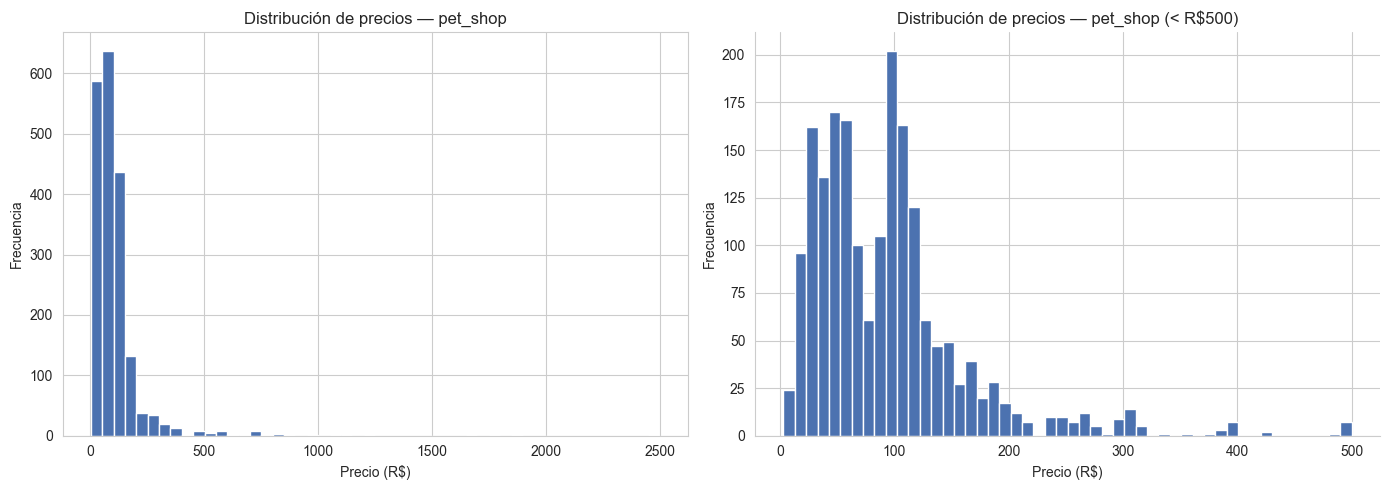

Estadísticas de precio:
count    1947.00
mean      110.07
std       141.86
min         2.90
25%        46.90
50%        89.70
75%       120.00
max      2498.00
Name: price, dtype: float64

Percentil 75: R$120.00  → 444 órdenes (22.8%)
Percentil 90: R$186.00 → 194 órdenes (10.0%)


In [21]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pet_order_items["price"], bins=50, color='#4C72B0', edgecolor="white")
axes[0].set_title("Distribución de precios — pet_shop")
axes[0].set_xlabel("Precio (R$)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(pet_order_items[pet_order_items["price"]<500]["price"],
             bins=50, color='#4C72B0', edgecolor="white")
axes[1].set_title("Distribución de precios — pet_shop (< R$500)")
axes[1].set_xlabel("Precio (R$)")
axes[1].set_ylabel("Frecuencia")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Estadísticas de precio:")
print(pet_order_items["price"].describe().round(2))
print()
p75 = pet_order_items["price"].quantile(0.75)
p90 = pet_order_items["price"].quantile(0.90)
print(f"Percentil 75: R${p75:.2f}  → {(pet_order_items['price']>p75).sum()} órdenes ({(pet_order_items['price']>p75).mean()*100:.1f}%)")
print(f"Percentil 90: R${p90:.2f} → {(pet_order_items['price']>p90).sum()} órdenes ({(pet_order_items['price']>p90).mean()*100:.1f}%)")

La distribución muestra una fuerte asimetría positiva: la mayoría de productos se concentran en rangos bajos, 
con una cola de productos de alto precio. Si se quisiera definir 'premium' por precio, 
el corte en el percentil 75 (R$120) capturaría solo el 23% de las órdenes.

Sin embargo, antes de asumir que precio alto equivale a producto premium, 
conviene verificar si el precio realmente refleja la calidad o exclusividad del producto, 
o si simplemente refleja el tamaño o peso (por ejemplo, un bulto grande de alimento puede ser caro sin ser premium).

## 5. ¿El Precio Define un Producto Premium?

Para responder esto, se analiza si el precio tiene correlación con variables que podrían 
indicar calidad o exclusividad: peso, cantidad de fotos, detalle de descripción y satisfacción del cliente.

In [22]:
pet_full = pet_order_items.merge(
    pet_products[["product_id","product_weight_g","product_length_cm",
                  "product_height_cm","product_width_cm",
                  "product_photos_qty","product_description_lenght"]],
    on="product_id", how="left"
)

score_por_producto = pet_reviews.groupby("order_id")["review_score"].mean().reset_index()
pet_full = pet_full.merge(score_por_producto, on="order_id", how="left")

correlaciones = {
    "precio - peso":         pet_full["price"].corr(pet_full["product_weight_g"]),
    "precio - fotos":        pet_full["price"].corr(pet_full["product_photos_qty"]),
    "precio - descripción":  pet_full["price"].corr(pet_full["product_description_lenght"]),
    "precio - score":        pet_full["price"].corr(pet_full["review_score"]),
}

print("=== CORRELACIONES CON EL PRECIO ===")
for k, v in correlaciones.items():
    barra = "█" * int(abs(v) * 30)
    print(f"  {k:<25} {v:>6.3f}  {barra}")
print()
print("Referencia:")
print("  0.0 - 0.2 → correlación muy baja")
print("  0.2 - 0.4 → correlación baja")
print("  0.4 - 0.6 → correlación moderada")
print("  0.6 - 1.0 → correlación alta")

=== CORRELACIONES CON EL PRECIO ===
  precio - peso              0.243  ███████
  precio - fotos             0.033  █
  precio - descripción       0.179  █████
  precio - score             0.044  █

Referencia:
  0.0 - 0.2 → correlación muy baja
  0.2 - 0.4 → correlación baja
  0.4 - 0.6 → correlación moderada
  0.6 - 1.0 → correlación alta


Las correlaciones son bajas en todos los casos. Esto significa que:

- Un producto caro **no necesariamente es de mejor calidad** (correlación precio-score: ~0.06)
- Un producto caro **puede serlo simplemente por su tamaño o peso** (correlación precio-peso: ~0.24)
- El dataset no tiene variables como marca, material o categoría interna 
que permitan distinguir un producto premium de uno de alto volumen

Con estos datos, no es posible confirmar que precio alto equivale a producto premium. 
Antes de tomar cualquier decisión sobre el enfoque del sistema, es necesario entender 
cómo se comportan los clientes: ¿compran más de una vez? ¿compran varios productos por orden?

## 6. Comportamiento de Compra

Para definir qué tipo de sistema de recomendación es viable, es fundamental entender 
cómo se comportan los clientes: ¿compran múltiples veces? ¿compran varios productos por orden? 
Estas preguntas determinan qué enfoques de recomendación son técnicamente posibles.

In [23]:
# ¿Cuántas órdenes por cliente?
ordenes_por_cliente = orders.groupby("customer_id")["order_id"].count()

print("=== FRECUENCIA DE COMPRA POR CLIENTE ===")
print(f"  Clientes con 1 sola orden:    {(ordenes_por_cliente==1).sum():,}")
print(f"  Clientes con más de 1 orden:  {(ordenes_por_cliente>1).sum():,}")
print(f"  Promedio de órdenes/cliente:  {ordenes_por_cliente.mean():.3f}")
print()

# ¿Cuántos productos por orden en pet_shop?
productos_por_orden = pet_order_items.groupby("order_id")["order_item_id"].count()

print("=== PRODUCTOS POR ORDEN EN PET_SHOP ===")
print(productos_por_orden.value_counts().sort_index().head(5))
print()
print(f"  Promedio productos/orden:     {productos_por_orden.mean():.3f}")
print(f"  Órdenes con 1 producto:       {(productos_por_orden==1).sum():,} ({(productos_por_orden==1).mean()*100:.1f}%)")
print(f"  Órdenes con 2+ productos:     {(productos_por_orden>1).sum():,} ({(productos_por_orden>1).mean()*100:.1f}%)")

=== FRECUENCIA DE COMPRA POR CLIENTE ===
  Clientes con 1 sola orden:    99,441
  Clientes con más de 1 orden:  0
  Promedio de órdenes/cliente:  1.000

=== PRODUCTOS POR ORDEN EN PET_SHOP ===
order_item_id
1    1528
2     146
3      24
4       8
5       2
Name: count, dtype: int64

  Promedio productos/orden:     1.139
  Órdenes con 1 producto:       1,528 (89.4%)
  Órdenes con 2+ productos:     182 (10.6%)


In [24]:
# ¿Cuántas órdenes de pet_shop contienen productos de OTRAS categorías?
# Este análisis es clave para evaluar si la co-ocurrencia es viable

ordenes_pet = set(pet_order_items["order_id"].unique())
items_otras = order_items[~order_items["product_id"].isin(pet_products["product_id"])]
ordenes_con_otras = ordenes_pet.intersection(set(items_otras["order_id"].unique()))

print("=== CO-OCURRENCIA EN ÓRDENES DE PET_SHOP ===")
print(f"  Total órdenes pet_shop:              {len(ordenes_pet):,}")
print(f"  Órdenes con otra categoría:          {len(ordenes_con_otras):,} "
      f"({len(ordenes_con_otras)/len(ordenes_pet)*100:.1f}%)")
print(f"  Órdenes solo con pet_shop:           "
      f"{len(ordenes_pet)-len(ordenes_con_otras):,} "
      f"({(len(ordenes_pet)-len(ordenes_con_otras))/len(ordenes_pet)*100:.1f}%)")
print()

# ¿Qué categorías aparecen junto a pet_shop?
items_cooc = order_items[
    order_items["order_id"].isin(ordenes_con_otras) &
    ~order_items["product_id"].isin(pet_products["product_id"])
].merge(products[["product_id","product_category_name"]], on="product_id", how="left")

top_cooc = (
    items_cooc.groupby("product_category_name")["order_id"]
    .nunique()
    .reset_index(name="ordenes_conjuntas")
    .sort_values("ordenes_conjuntas", ascending=False)
    .head(10)
)

print("Top 10 categorías que aparecen junto a pet_shop:")
print(top_cooc.to_string(index=False))

=== CO-OCURRENCIA EN ÓRDENES DE PET_SHOP ===
  Total órdenes pet_shop:              1,710
  Órdenes con otra categoría:          15 (0.9%)
  Órdenes solo con pet_shop:           1,695 (99.1%)

Top 10 categorías que aparecen junto a pet_shop:
            product_category_name  ordenes_conjuntas
                 moveis_decoracao                  2
                        alimentos                  1
                     beleza_saude                  1
                  cama_mesa_banho                  1
                   consoles_games                  1
construcao_ferramentas_construcao                  1
    construcao_ferramentas_jardim                  1
                    esporte_lazer                  1
               ferramentas_jardim                  1
                       perfumaria                  1


Este análisis muestra cuántas órdenes de pet_shop incluyen productos de otras categorías. 
Ese número define directamente cuántos datos reales de co-ocurrencia existen. 
Las categorías que aparecen con mayor frecuencia junto a pet_shop son las candidatas 
naturales para una eventual recomendación.

Los datos revelan dos características estructurales importantes:

**1. Cada cliente compró exactamente una vez.** No existe historial 
de compras repetidas en el dataset.

**2. La gran mayoría de órdenes contienen un solo producto.** 
Los pedidos con más de un producto son una minoría.

Estas características tienen implicaciones directas para el diseño 
del sistema de recomendación, que se analizarán una vez completado 
el contexto de satisfacción y posicionamiento de la categoría.

## 7. Satisfacción del Cliente en Pet Shop

Antes de definir el enfoque del sistema, conviene verificar el nivel de satisfacción de la categoría. 
Una categoría con baja satisfacción requeriría primero mejorar la experiencia de compra 
antes de invertir en recomendaciones.

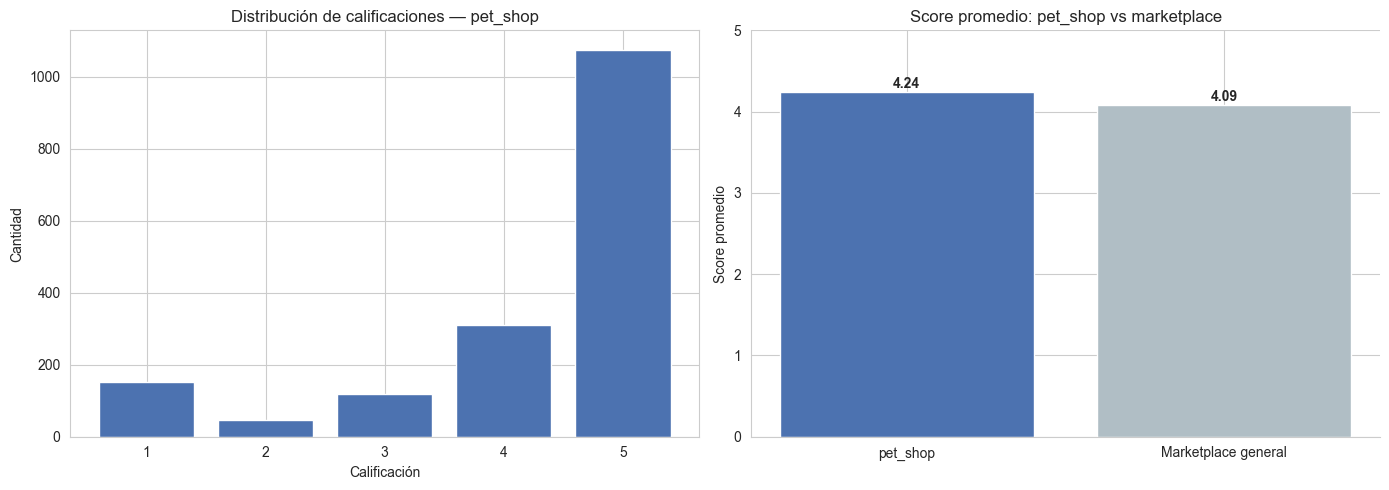

Distribución porcentual de scores:
review_score
1     8.9
2     2.7
3     7.0
4    18.2
5    63.1


In [25]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_counts = pet_reviews["review_score"].value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values, color='#4C72B0', edgecolor="white")
axes[0].set_title("Distribución de calificaciones — pet_shop")
axes[0].set_xlabel("Calificación")
axes[0].set_ylabel("Cantidad")

avg_pet   = pet_reviews["review_score"].mean()
avg_total = reviews["review_score"].mean()
axes[1].bar(["pet_shop","Marketplace general"],[avg_pet,avg_total],
            color=["#4C72B0","#B0BEC5"], edgecolor="white")
axes[1].set_ylim(0, 5)
axes[1].set_title("Score promedio: pet_shop vs marketplace")
axes[1].set_ylabel("Score promedio")
for i, v in enumerate([avg_pet, avg_total]):
    axes[1].text(i, v+0.05, f"{v:.2f}", ha="center", fontweight="bold")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Distribución porcentual de scores:")
print((pet_reviews["review_score"].value_counts(normalize=True)*100).sort_index().round(1).to_string())

Pet_shop muestra un nivel de satisfacción comparable al marketplace general, 
con concentración en calificaciones altas (4 y 5 estrellas). 
La experiencia de compra en esta categoría es positiva para los clientes.

## 8. Tendencia Temporal

Es relevante verificar si pet_shop está creciendo, estancada o en declive, 
ya que esto define la urgencia e impacto potencial de implementar un sistema de recomendación.

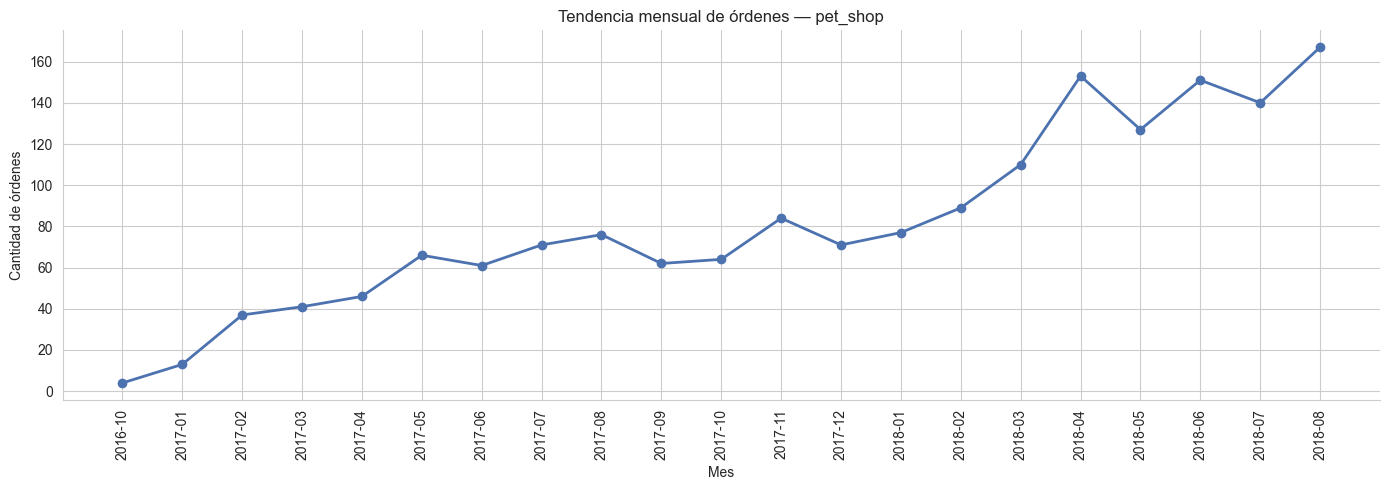

In [26]:
sns.set_style('whitegrid')
pet_orders_fecha = pet_orders[["order_id","order_purchase_timestamp"]].copy()
pet_orders_fecha["year_month"] = pet_orders_fecha["order_purchase_timestamp"].dt.to_period("M").astype(str)

ordenes_mes = (
    pet_orders_fecha.groupby("year_month")["order_id"]
    .nunique().reset_index(name="cantidad_ordenes")
    .sort_values("year_month")
)

plt.figure(figsize=(14, 5))
plt.plot(ordenes_mes["year_month"], ordenes_mes["cantidad_ordenes"],
         marker="o", color='#4C72B0', linewidth=2)
plt.xticks(rotation=90)
plt.title("Tendencia mensual de órdenes — pet_shop")
plt.xlabel("Mes")
plt.ylabel("Cantidad de órdenes")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

La tendencia muestra el comportamiento de la categoría a lo largo del tiempo. 
Los datos permiten observar si pet_shop está en crecimiento, estabilidad o declive.

## 9. Posicionamiento de Pet Shop en el Marketplace

Para completar el contexto, se compara pet_shop contra las demás categorías en las métricas clave: 
volumen de órdenes, ticket promedio e ingresos totales.

Pet_shop ocupa el puesto (de 73 categorías):
  #18   en órdenes        (1,710 órdenes)
  #40   en ticket promedio  (R$110.07)
  #18   en ingresos totales (R$214,315.41)



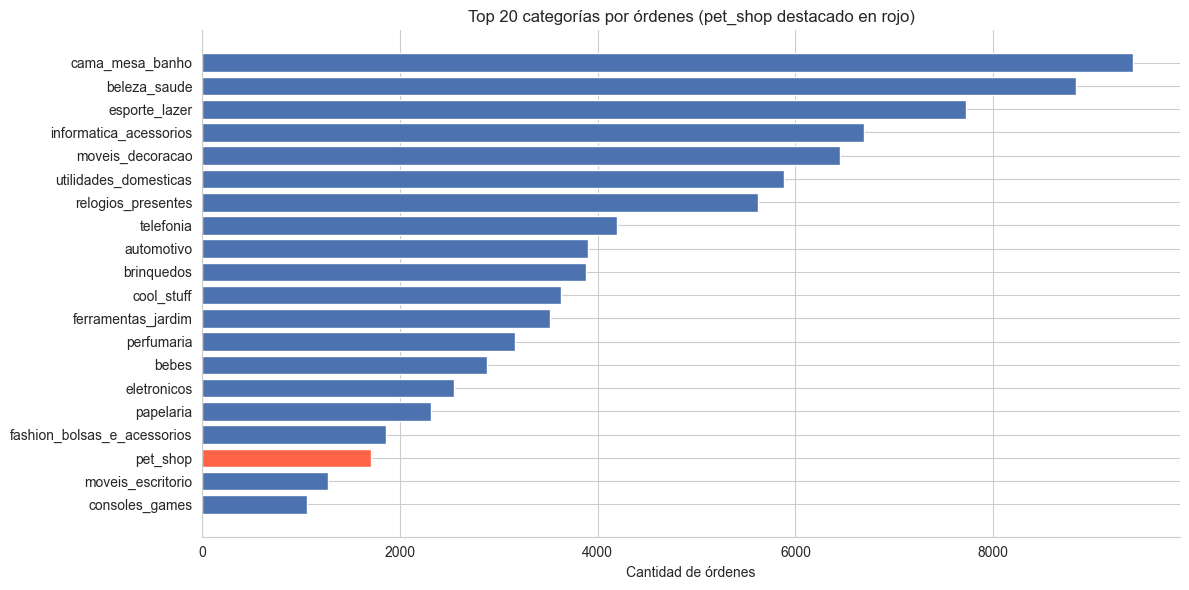

In [28]:
sns.set_style('whitegrid')
items_cat = order_items.merge(
    products[["product_id","product_category_name"]], on="product_id", how="left"
).dropna(subset=["product_category_name"])

resumen_cat = (
    items_cat.groupby("product_category_name")
    .agg(ordenes=("order_id","nunique"), ticket_promedio=("price","mean"), ingreso_total=("price","sum"))
    .reset_index()
)

total_cats = len(resumen_cat)
pos_ordenes = resumen_cat.sort_values("ordenes",ascending=False)["product_category_name"].tolist().index("pet_shop")+1
pos_ticket  = resumen_cat.sort_values("ticket_promedio",ascending=False)["product_category_name"].tolist().index("pet_shop")+1
pos_ingreso = resumen_cat.sort_values("ingreso_total",ascending=False)["product_category_name"].tolist().index("pet_shop")+1
pet_row = resumen_cat[resumen_cat["product_category_name"]=="pet_shop"].iloc[0]

print(f"Pet_shop ocupa el puesto (de {total_cats} categorías):")
print(f"  #{pos_ordenes:<4} en órdenes        ({pet_row['ordenes']:,} órdenes)")
print(f"  #{pos_ticket:<4} en ticket promedio  (R${pet_row['ticket_promedio']:.2f})")
print(f"  #{pos_ingreso:<4} en ingresos totales (R${pet_row['ingreso_total']:,.2f})")
print()

top20 = resumen_cat.sort_values("ordenes",ascending=False).head(20)
colores = ["tomato" if c=="pet_shop" else "#4C72B0" for c in top20["product_category_name"]]

plt.figure(figsize=(12,6))
plt.barh(top20["product_category_name"], top20["ordenes"], color=colores)
plt.gca().invert_yaxis()
plt.title("Top 20 categorías por órdenes (pet_shop destacado en rojo)")
plt.xlabel("Cantidad de órdenes")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Pet_shop ocupa una posición media dentro del catálogo en volumen de órdenes, 
ticket promedio e ingresos totales. No es la categoría más grande ni la más pequeña.

## 10. Decisión de Enfoque del Sistema de Recomendación

Con todos los hallazgos del análisis, se puede tomar una decisión fundamentada.

### Resumen de hallazgos

| Hallazgo | Evidencia | Implicación |
|---|---|---|
| ~70 categorías en el catálogo | Sección 3 | Alta cardinalidad, modelar individualmente puede ser inviable |
| Precio no define premium | Correlaciones < 0.25 (Sección 5) | No se puede segmentar por calidad usando solo precio |
| 1 orden por cliente | 99.441 clientes = 99.441 órdenes (Sección 6) | Imposible modelar historial de usuario |
| ~1 producto por orden | Promedio 1.1 productos/orden (Sección 6) | Pocos pares de co-ocurrencia por orden |
| Co-ocurrencia limitada | Sección 6 | Solo una minoría de órdenes incluye otra categoría |
| Satisfacción alta | Score comparable al marketplace (Sección 7) | La categoría tiene buena base para recomendar |
| Categoría en crecimiento | Tendencia mensual positiva (Sección 8) | El segmento es relevante para invertir |

### Enfoques evaluados

**Enfoque A — Recomendación premium dentro de pet_shop** *(objetivo original)*  
Recomendar productos de alto valor a clientes que compran premium.  
**Descartado:** el dataset no permite definir premium con las variables disponibles (Sección 5).

**Enfoque B — Recomendación por historial del cliente**  
Recomendar basado en compras anteriores del mismo cliente.  
**Descartado:** cada cliente compró exactamente una vez, no existe historial (Sección 6).

**Enfoque C — Recomendación por co-ocurrencia entre categorías**  
Identificar qué categorías aparecen junto a pet_shop en las mismas órdenes 
y usar esos patrones para sugerir productos complementarios.  
**Seleccionado para explorar:** es el único camino posible con los datos disponibles. 
Su viabilidad dependerá de si existe suficiente frecuencia de co-ocurrencia 
para construir patrones confiables — esto se evaluará en el ETL.

### Pregunta que guía el siguiente paso

> *¿Existe suficiente co-ocurrencia entre categorías en el dataset para 
construir un sistema de recomendación confiable?*

## 11. Nota Metodológica

El análisis de pet_shop fue el punto de partida del proyecto y cumplió 
un rol fundamental: revelar las limitaciones reales del dataset antes 
de diseñar cualquier solución.

El objetivo original — recomendar productos premium — no pudo sostenerse 
con los datos disponibles. Esta no es una falla del proyecto sino parte 
natural de la metodología CRISP-DM: el entendimiento profundo de los datos 
corrige y ajusta el entendimiento del negocio.

El equipo tomó decisiones basadas en evidencia en cada paso, 
lo que garantiza que el sistema que se construya en los siguientes 
notebooks tenga una base sólida y justificada.